In [2]:
import pandas as pd
train_df = pd.read_csv('train_aWnotuB.csv')
test_df = pd.read_csv('datasets_8494_11879_test_BdBKkAj.csv')
print("---Training Dataset Preview---")
print(train_df.head())


---Training Dataset Preview---
              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041


In [4]:
train_df['DateTime'] = pd.to_datetime(train_df['DateTime'])
train_df['Year'] = train_df['DateTime'].dt.year
train_df['Month'] = train_df['DateTime'].dt.month
train_df['Day'] = train_df['DateTime'].dt.day
train_df['Hour'] = train_df['DateTime'].dt.hour
train_df['DayOfWeek'] = train_df['DateTime'].dt.dayofweek
train_df['IsWeekend'] = train_df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
print("---Updated Dataset with Time Features---")
print(train_df[['DateTime', 'Hour', 'DayOfWeek', 'IsWeekend', 'Vehicles']].head())

---Updated Dataset with Time Features---
             DateTime  Hour  DayOfWeek  IsWeekend  Vehicles
0 2015-11-01 00:00:00     0          6          1        15
1 2015-11-01 01:00:00     1          6          1        13
2 2015-11-01 02:00:00     2          6          1        10
3 2015-11-01 03:00:00     3          6          1         7
4 2015-11-01 04:00:00     4          6          1         9


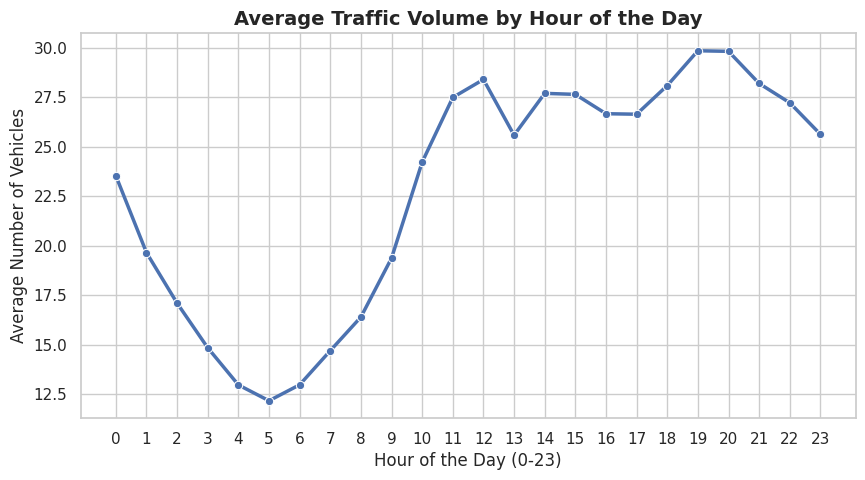

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
hourly_traffic = train_df.groupby('Hour')['Vehicles'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_traffic, x='Hour', y='Vehicles', marker='o', color='b', linewidth=2.5)
plt.title('Average Traffic Volume by Hour of the Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average Number of Vehicles', fontsize=12)
plt.xticks(range(0,24))
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
test_df['DateTime'] = pd.to_datetime(test_df['DateTime'])
test_df['Year'] = test_df['DateTime'].dt.year
test_df['Month'] = test_df['DateTime'].dt.month
test_df['Day'] = test_df['DateTime'].dt.day
test_df['Hour'] = test_df['DateTime'].dt.hour
test_df['DayOfWeek'] = test_df['DateTime'].dt.dayofweek
test_df['IsWeekend'] = test_df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
features = ['Junction', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'IsWeekend']
X = train_df[features]
y = train_df['Vehicles']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
print("Training the model... Please wait a few seconds...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("\n--- Model Training Complete ---")
print(f"Validation Mean Absolute Error (MAE): {mae:.2f} vehicles")
print(f"Validation Root Mean Squared Error (RMSE): {rmse:.2f} vehicles")

Training the model... Please wait a few seconds...

--- Model Training Complete ---
Validation Mean Absolute Error (MAE): 10.62 vehicles
Validation Root Mean Squared Error (RMSE): 13.60 vehicles


In [8]:
test_features = test_df[features]
test_predictions = model.predict(test_features)
test_df['Vehicles'] = test_predictions
submission_df = test_df[['ID', 'Vehicles']]
submission_file_name = 'traffic_predictions_submission.csv'
submission_df.to_csv(submission_file_name, index=False)
print(f"--- Predictions Saved Successfully ---")
print(f"Your file has been saved as: '{submission_file_name}'")
print("\nFirst 5 rows of your final predictions:")
print(submission_df.head())

--- Predictions Saved Successfully ---
Your file has been saved as: 'traffic_predictions_submission.csv'

First 5 rows of your final predictions:
            ID  Vehicles
0  20170701001     68.40
1  20170701011     60.18
2  20170701021     47.05
3  20170701031     38.54
4  20170701041     32.05
